# Biblioteca Cogroo

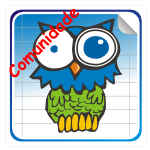
*   Biblioteca desenvolvida em java mas hoje existe uma interface para acessá-la em python, a Cogroo4py.

# Vantagens ao usar a biblioteca Cogroo4py:


*   **Foco na língua portuguesa**
*   **Reconhecimento de erros complexos:**

Correções para erros complexos como concordância nominal e verbal, algo que é mais difícil de tratar com outras bibliotecas de NLP.

*   **Correção Gramatical e Ortográfica:**

Além das tarefas comuns de NLP, o Cogroo4Py permite detectar e corrigir erros gramaticais e ortográficos em textos em português.

# Desvantagens ao usar a biblioteca Cogroo4py:


*   **Desempenho**

Como a biblioteca Cogroo4Py é uma interface para o Cogroo, que é uma ferramenta originalmente desenvolvida em Java, o desempenho pode ser inferior em comparação com bibliotecas de NLP nativas de Python, como SpaCy ou NLTK, especialmente quando processando grandes volumes de texto.
*   **Comunidade e Documentação Limitadas**

Comparado com bibliotecas de NLP mais populares, o Cogroo4Py tem uma comunidade menor e menos recursos de documentação, o que pode dificultar a solução de problemas ou o aprendizado para novos usuários.

* **Foco limitado em NLP Geral**

O Cogroo4Py é mais focado em correção gramatical e linguística do que em outras tarefas amplamente usadas em NLP, como geração de texto, modelagem de tópicos, ou aprendizado profundo (deep learning). Isso pode limitar seu uso para aplicações de NLP mais modernas.









In [ ]:
pip install cogroo4py

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.7/32.7 MB 50.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 465.3/465.3 kB 26.7 MB/s eta 0:00:00
  Attempting uninstall: Deprecated
    Found existing installation: Deprecated 1.2.14
    Uninstalling Deprecated-1.2.14:
      Successfully uninstalled Deprecated-1.2.14


Importando a biblioteca e inicializando:

In [ ]:
from cogroo4py.cogroo import Cogroo
cogroo = Cogroo()

Exemplo de Lematização:

In [ ]:
cogroo.lemmatize('Estas laranjas estão deliciosas.')

'este laranja estar delicioso .'

O corretor gramatical do CoGrOO verifica a colocação pronominal, concordância nominal, concordância entre sujeito e verbo, concordância verbal, uso de crase, regência nominal, regência verbal e outros erros comuns da língua portuguesa escrita.

Exemplo do corretor gramatical:

In [ ]:
doc = cogroo.grammar_check('Ela começou à estudar.')
doc.mistakes


[[xml:4] Não acontece crase antes de verbo.]

### 2ª)Mostre uma tabela com resultados da pesquisa sobre os significados das siglas pos tagging que foram calculadas pela spaCy.

In [15]:
pip install spacy

In [5]:
!python -m spacy download pt_core_news_sm


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 40.0 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [22]:
import spacy
import pandas as pd
from spacy.lang.pt.examples import sentences
from nltk.stem import RSLPStemmer
import nltk


In [23]:
nlp = spacy.load("pt_core_news_sm")
doc = nlp(sentences[0])
print(doc.text)
for token in doc:
  print(token.text, token.pos_)

Apple está querendo comprar uma startup do Reino Unido por 100 milhões de dólares
Apple PROPN
está AUX
querendo VERB
comprar VERB
uma DET
startup NOUN
do ADP
Reino PROPN
Unido PROPN
por ADP
100 NUM
milhões NUM
de ADP
dólares NOUN


In [24]:
dados = [(token.text, token.pos_, token.pos_) for token in doc]

df = pd.DataFrame(dados, columns=["Palavra", "POS", "Significado da Sigla POS"])

pos_significado = {
    "PROPN": "Proper Noun (Nome próprio)",
    "AUX": "Auxiliary (Verbo auxiliar)",
    "VERB": "Verb (Verbo)",
    "DET": "Determiner (Determinante)",
    "NOUN": "Noun (Substantivo)",
    "ADP": "Adposition (Preposição)",
    "NUM": "Numeral (Número)"
}

df["Significado da Sigla POS"] = df["POS"].map(pos_significado)

df

,Palavra,POS,Significado da Sigla POS
0,Apple,PROPN,Proper Noun (Nome próprio)
1,está,AUX,Auxiliary (Verbo auxiliar)
2,querendo,VERB,Verb (Verbo)
3,comprar,VERB,Verb (Verbo)
4,uma,DET,Determiner (Determinante)
5,startup,NOUN,Noun (Substantivo)
6,do,ADP,Adposition (Preposição)
7,Reino,PROPN,Proper Noun (Nome próprio)
8,Unido,PROPN,Proper Noun (Nome próprio)
9,por,ADP,Adposition (Preposição)


### 3ª) Faça uma implementação para que sua aplicação receba um texto com erros gramaticais em português.
1. Realize a correção do texto
2. Tokenize o texto
3. Remova as stop words
4. Faça uma tabela mostrando 3 colunas para todos os tokens: token , stemming e lematização.


In [8]:
!pip install language-tool-python
!pip install enelvo


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.9/240.9 kB 3.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.5/27.5 MB 27.9 MB/s eta 0:00:00
  Created wheel for emoji: filename=emoji-2.2.0-py3-none-any.whl size=234910 sha256=3363b809079352c26729bd5ca6fdd14574a16011a21a88b8f5426ebdd6933931
  Stored in directory: /root/.cache/pip/wheels/02/3d/88/51a592b9ad17e7899126563698b4e3961983ebe85747228ba6
Successfully built emoji


Usando a biblioteca Enelvo para corrigir o texto:



In [18]:
from enelvo.normaliser import Normaliser

norm = Normaliser(tokenizer='readable', capitalize_inis=True,
                  capitalize_pns=True, capitalize_acs=True,
                  sanitize=False)

texto = "oi alice, como vc ta? paulo disse q hj vc fautou aula"
resposta = norm.normalise(texto)
print(resposta)

Oi Alice , como você está ? Paulo disse que hoje você faltou aula


In [25]:
nltk.download('rslp')

[nltk_data] Downloading package rslp to /root/nltk_data...
[nltk_data]   Unzipping stemmers/rslp.zip.


True

Utilizando spacy e nltk para realizar as tarefas dos itens 2, 3 e 4:

In [28]:
doc = nlp(resposta)
stemmer = RSLPStemmer()

data = []

for token in doc:
    if not token.is_stop and token.is_alpha:
        lemma = token.lemma_
        stem = stemmer.stem(token.text)
        data.append([token.text, stem, lemma])


df = pd.DataFrame(data, columns=["Token", "Stemming", "Lematização"])

print("\nTabela de Tokens, Stemming e Lematização:")
print(df)


Tabela de Tokens, Stemming e Lematização:
    Token Stemming Lematização
0      Oi       oi          Oi
1   Alice     alic       Alice
2   Paulo     paul       Paulo
3   disse     diss       dizer
4    hoje      hoj        hoje
5  faltou     falt      faltar
6    aula      aul        aula
